<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

<a id="table-of-contents"></a>

## Table of Contents:

- [Imports](#imports)
- [Notebook Notes](#notebook-notes)
- [Load Discussion Artifacts](#load-discussion-artifacts)
- [Model Performance Comparison](#model-performance-comparison)
- [Feature Count and Selected Features](#feature-count-and-selected-features)
- [Performance Retention](#performance-retention)
- [Information Gain Results](#information-gain-results)
- [Random Forest Feature Importance](#random-forest-feature-importance)
- [GridSearchCV Results](#gridsearchcv-results)
- [Final Discussion Summary](#final-discussion-summary)
- [Save Discussion Outputs](#save-discussion-outputs)
- [Run Full Discussion Workflow](#run-full-discussion-workflow)

</div>


##### **IMPORTANT**:
- YOU MUST HAVE THE SAVED HIGHEST-SNR METRICS JSON FILES IN `../Models/`
- YOU MUST HAVE THE FEATURE EXPLORATION CSV FILES IN `../Reports/`
- This notebook is a discussion/reporting layer; it does **not** retrain models
- The plotting helpers add grids and bar labels so figures are presentation-ready

---

##### **ORIENTATION**:
- This notebook follows the highest-SNR series from raw I/Q baseline to engineered features to selected top information-gain features
- The main comparison is between:
  - Raw flattened I/Q Random Forest baseline
  - Random Forest trained on all engineered features
  - Random Forest trained on the top selected information-gain features
- Feature counts are detected from the saved artifacts so the notebook reflects your local run

---

##### **SUMMARY**:
- The discussion should emphasize the tradeoff between model complexity and performance retention
- The selected-feature model used the top 25 information-gain features and preserved most of the all-feature model's performance
- The performance visualizations support the narrative that a smaller, more interpretable feature set can maintain strong classification performance


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>


In [21]:
import os
import sys
import importlib

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Allow imports from the Code directory when this notebook is run from a Notebooks directory
CODE_DIR = '../Code'
if os.path.exists(CODE_DIR) and CODE_DIR not in sys.path:
    sys.path.append(CODE_DIR)

# Discussion helper module
import highest_snr_discussion as d
importlib.reload(d)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Notebook Notes

- [Back to Table of Contents](#table-of-contents)

</div>


This notebook is the discussion step for the highest-SNR project series.

The expected project flow is:

```text
1. highest_snr_baseline.py / .ipynb
   - Train baseline Random Forest on flattened raw I/Q samples
   - Save baseline model metrics JSON

2. highest_snr_feature_engineering.py / .ipynb
   - Create engineered signal features from the reduced highest-SNR .hdf5 dataset
   - Save the feature-engineered DataFrame

3. highest_snr_feature_engineering_explore.py / .ipynb
   - Rank engineered features by information gain / mutual information
   - Train an exploratory Random Forest on all engineered features
   - Save feature rankings and all-feature model metrics

4. highest_snr_feature_engineering_modeling.py / .ipynb
   - Train and tune a Random Forest using selected top information-gain features
   - Save selected-feature model metrics JSON

5. highest_snr_discussion.py / .ipynb
   - Load all saved artifacts
   - Compare model performance and feature-count tradeoffs
   - Create discussion-ready tables, plots, and keypoints
```


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Load Discussion Artifacts

- [Back to Table of Contents](#table-of-contents)

</div>


This section loads saved JSON and CSV artifacts. It should be run before any comparison, plot, or discussion summary cells.

In [2]:
artifacts = d.load_discussion_artifacts(
    baseline_metrics_path=d.BASELINE_METRICS_PATH,
    all_feature_metrics_path=d.ALL_FEATURE_METRICS_PATH,
    top_feature_metrics_path=d.TOP_FEATURE_METRICS_PATH,
    gridsearch_cv_results_path=d.GRIDSEARCH_CV_RESULTS_PATH,
    feature_exploration_path=d.FEATURE_EXPLORATION_PATH,
    feature_quality_path=d.FEATURE_QUALITY_PATH,
    selected_features_path=d.SELECTED_FEATURES_PATH
)


Discussion artifacts loaded successfully!
Loaded artifacts:
- baseline_metrics
- all_feature_metrics
- top_feature_metrics
- gridsearch_cv_results
- feature_exploration
- feature_quality
- selected_features



<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Model Performance Comparison

- [Back to Table of Contents](#table-of-contents)

</div>


This section compares the major highest-SNR model stages using accuracy, weighted precision, weighted recall, and weighted ROC-AUC.

The bar chart includes a grid, legend, and numeric labels on each bar so it can be used directly in a report or presentation.

In [3]:
model_comparison_df = d.create_model_comparison_dataframe(artifacts)

model_comparison_display = model_comparison_df.copy()
for metric in d.METRIC_COLUMNS:
    model_comparison_display[metric] = model_comparison_display[metric].round(4)

display(model_comparison_display)


,model_key,model_name,input_type,num_features_used,accuracy,precision_weighted,recall_weighted,roc_auc_ovr_weighted
0,baseline,Raw I/Q RFC Baseline,flattened_raw_iq,2048,0.3621,0.3401,0.3621,0.8340
1,all_features,All Engineered Features RFC,engineered_features,105,0.7217,0.7120,0.7217,0.9780
2,top_features,Top Selected Features RFC,selected_engineered_features,25,0.6938,0.6864,0.6938,0.9729


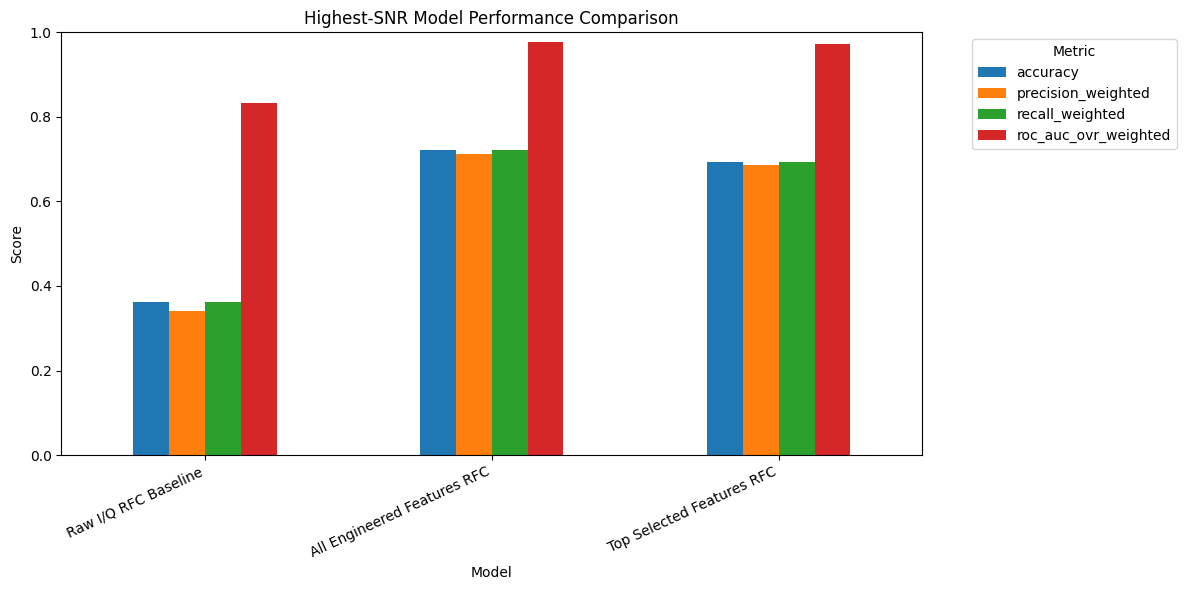

In [4]:
d.plot_model_performance_comparison(
    model_comparison_df=model_comparison_df,
    metrics=d.METRIC_COLUMNS,
    figsize=(12, 6)
)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Feature Count and Selected Features

- [Back to Table of Contents](#table-of-contents)

</div>


This section focuses on dimensionality reduction from all engineered features to the selected top information-gain features.

The selected-feature list is not an ordered sequence that the Random Forest is forced to split on from 1 to 25. It is the subset of features allowed into the selected-feature model.

In [5]:
feature_count_summary_df = d.create_feature_count_summary(artifacts)

display(feature_count_summary_df)

reduction_percent = feature_count_summary_df.attrs['reduction_from_all_to_top'] * 100
print(f"Feature reduction from all engineered features to selected features: {reduction_percent:.2f}%")


,feature_set,num_features,notes
0,Raw flattened I/Q baseline,2048,1024 I/Q samples flattened into 2048 raw values
1,All engineered features,105,Detected from feature-quality artifact; one ro...
2,Top selected features,25,Selected by information_gain


Feature reduction from all engineered features to selected features: 76.19%


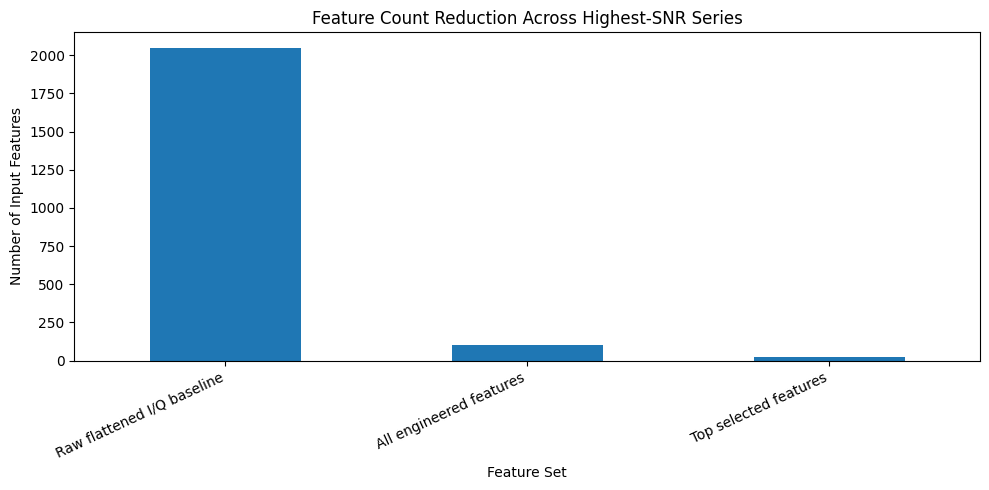

In [6]:
d.plot_feature_count_summary(
    feature_count_summary_df=feature_count_summary_df,
    figsize=(10, 5)
)


In [8]:
selected_features = artifacts['selected_features']
selected_feature_names = selected_features['selected_feature_names']

print('Selection method:', selected_features.get('selection_method'))
print('Number of selected features:', len(selected_feature_names))
print('Selected features:')
for idx, feature in enumerate(selected_feature_names, start=1):
    print(f'{idx}. {feature}')


Selection method: information_gain
Number of selected features: 25
Selected features:
1. magnitude_cv
2. radius_std
3. std_magnitude
4. power_cv
5. std_power
6. iqr_magnitude
7. max_power
8. max_magnitude
9. radius_unique_rounded_count
10. q75_magnitude
11. q25_magnitude
12. std_inst_freq
13. range_magnitude
14. radius_mean
15. mean_magnitude
16. kurtosis_magnitude
17. range_inst_freq
18. iqr_inst_freq
19. quadrant_balance_std
20. kurtosis_inst_freq
21. peak_to_average_power_ratio
22. std_phase
23. max_fft_magnitude
24. max_fft_power
25. std_fft_power


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Performance Retention

- [Back to Table of Contents](#table-of-contents)

</div>


This is one of the most important discussion sections.

It compares the selected-feature model against the all-feature engineered model and quantifies how much performance was retained after reducing the feature set.

In [9]:
performance_retention_df = d.create_performance_retention_dataframe(model_comparison_df)

performance_retention_display = performance_retention_df.copy()
for col in ['all_feature_model', 'top_feature_model', 'absolute_drop', 'retained_ratio']:
    performance_retention_display[col] = performance_retention_display[col].round(4)
performance_retention_display['absolute_drop_percentage_points'] = performance_retention_display['absolute_drop_percentage_points'].round(2)
performance_retention_display['retained_percent'] = performance_retention_display['retained_percent'].round(2)

display(performance_retention_display)


,metric,all_feature_model,top_feature_model,absolute_drop,absolute_drop_percentage_points,retained_ratio,retained_percent
0,accuracy,0.7217,0.6938,0.0279,2.79,0.9613,96.13
1,precision_weighted,0.7120,0.6864,0.0257,2.57,0.9640,96.40
2,recall_weighted,0.7217,0.6938,0.0279,2.79,0.9613,96.13
3,roc_auc_ovr_weighted,0.9780,0.9729,0.0051,0.51,0.9948,99.48


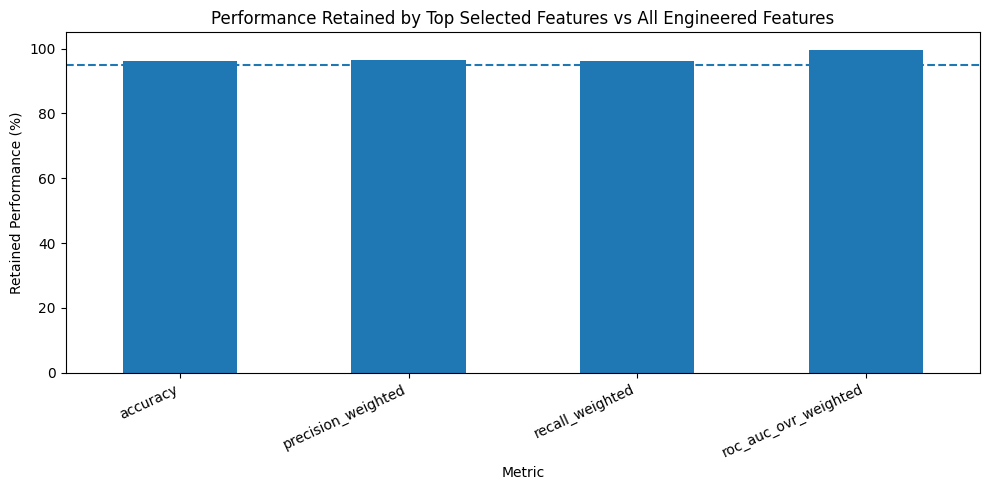

In [10]:
d.plot_performance_retention(
    performance_retention_df=performance_retention_df,
    figsize=(10, 5)
)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Information Gain Results

- [Back to Table of Contents](#table-of-contents)

</div>


This section shows the highest-ranked engineered features by information gain / mutual information.

Information gain is a univariate ranking, so a feature can be individually useful without being the only feature the model needs. The horizontal bar chart includes grid lines and value labels.

In [11]:
top_information_gain_df = d.get_top_information_gain_features(
    artifacts=artifacts,
    top_n=25
)

display(top_information_gain_df)


,feature,information_gain,information_gain_rank,random_forest_importance,random_forest_importance_rank
0,magnitude_cv,1.854914,1,0.021065,12
1,radius_std,1.650984,2,0.019088,17
2,std_magnitude,1.650967,3,0.021118,11
3,power_cv,1.641041,4,0.021975,9
4,std_power,1.623681,5,0.025369,4
5,iqr_magnitude,1.591323,6,0.028011,3
6,max_power,1.588247,7,0.019856,14
7,max_magnitude,1.588221,8,0.021028,13
8,radius_unique_rounded_count,1.547279,9,0.023866,6
9,q75_magnitude,1.545803,10,0.022418,7


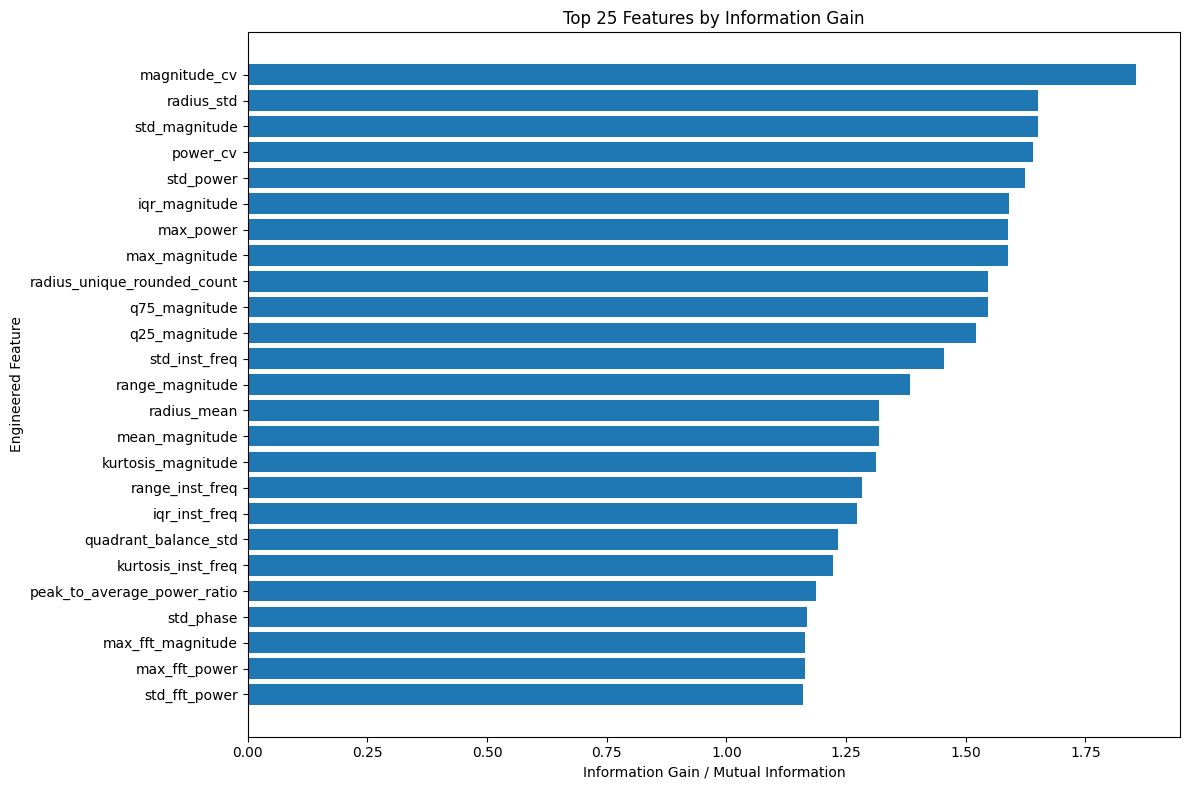

In [12]:
d.plot_top_information_gain_features(
    top_information_gain_df=top_information_gain_df,
    top_n=25,
    figsize=(12, 8)
)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Random Forest Feature Importance

- [Back to Table of Contents](#table-of-contents)

</div>


This section shows the model-based feature importance from the Random Forest trained on engineered features.

Use this ranking as a complement to information gain. Agreement between information gain and Random Forest importance strengthens the interpretation of which features matter.

In [13]:
top_random_forest_df = d.get_top_random_forest_features(
    artifacts=artifacts,
    top_n=25
)

display(top_random_forest_df)


,feature,information_gain,information_gain_rank,random_forest_importance,random_forest_importance_rank
0,phase_unique_rounded_count,1.112407,35,0.032524,1
1,std_inst_freq,1.454302,12,0.031261,2
2,iqr_magnitude,1.591323,6,0.028011,3
3,std_power,1.623681,5,0.025369,4
4,iqr_inst_freq,1.273802,18,0.024677,5
5,radius_unique_rounded_count,1.547279,9,0.023866,6
6,q75_magnitude,1.545803,10,0.022418,7
7,kurtosis_magnitude,1.312242,16,0.022196,8
8,power_cv,1.641041,4,0.021975,9
9,near_origin_ratio,0.854708,71,0.021636,10


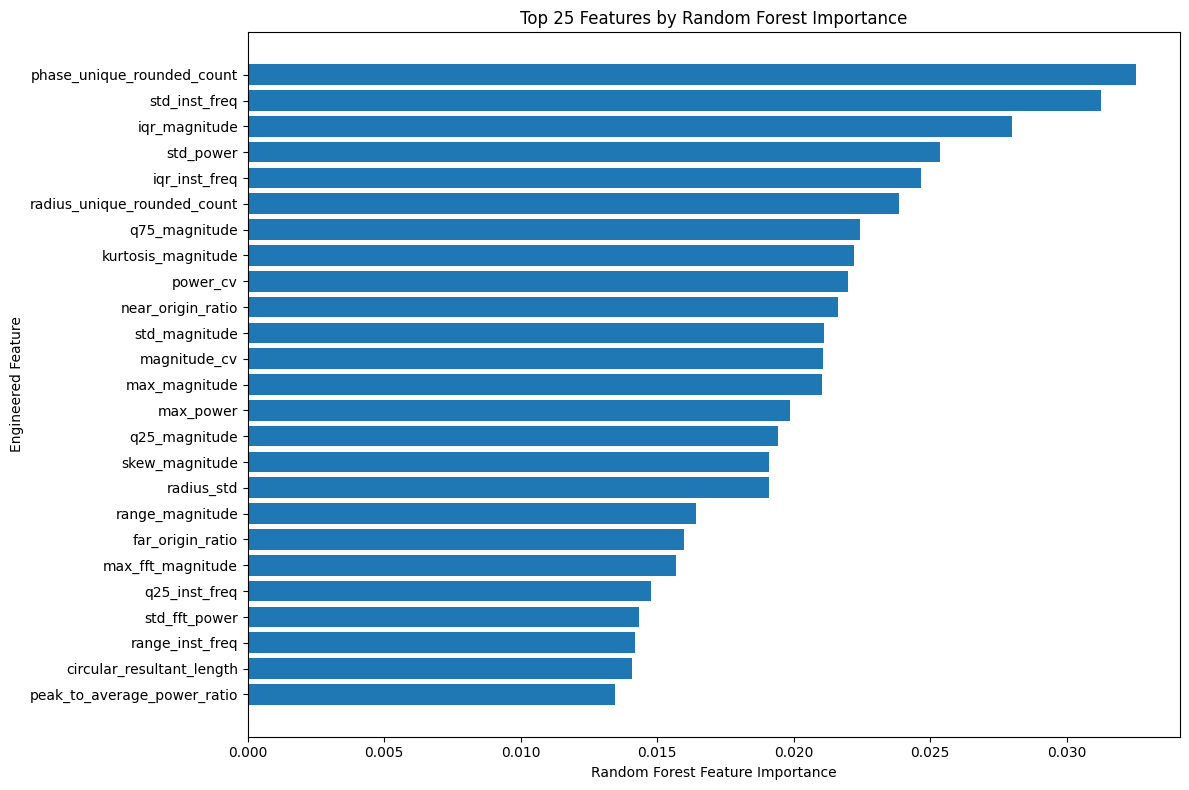

In [14]:
d.plot_top_random_forest_features(
    top_random_forest_df=top_random_forest_df,
    top_n=25,
    figsize=(12, 8)
)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## GridSearchCV Results

- [Back to Table of Contents](#table-of-contents)

</div>


This section reviews the top GridSearchCV parameter combinations for the selected-feature Random Forest model.

The plot shows the top mean CV ROC-AUC scores with a grid and score labels to make small differences easier to see.

In [15]:
gridsearch_summary_df = d.create_gridsearch_summary_dataframe(
    artifacts=artifacts,
    top_n=10
)

display(gridsearch_summary_df)


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features
0,1,0.970932,0.000563,0.999992,1.177946e-06,200,30.0,2,2,sqrt
1,2,0.970913,0.000622,0.999992,1.089027e-06,200,NaN,2,2,sqrt
2,3,0.970804,0.000573,0.999983,1.914339e-06,200,30.0,5,2,log2
3,4,0.970754,0.000467,0.999982,1.515620e-06,200,NaN,5,2,log2
4,5,0.970702,0.000581,0.999984,1.957427e-06,200,30.0,5,2,sqrt
5,6,0.970699,0.000683,0.999984,1.899948e-06,200,NaN,5,2,sqrt
6,7,0.970686,0.000743,0.999998,3.790523e-07,200,NaN,5,1,sqrt
7,8,0.970678,0.000808,0.999998,4.227667e-07,200,30.0,5,1,sqrt
8,9,0.970485,0.000678,0.999992,1.202926e-06,200,NaN,2,2,log2
9,10,0.970471,0.000557,0.999997,6.608314e-07,200,30.0,5,1,log2


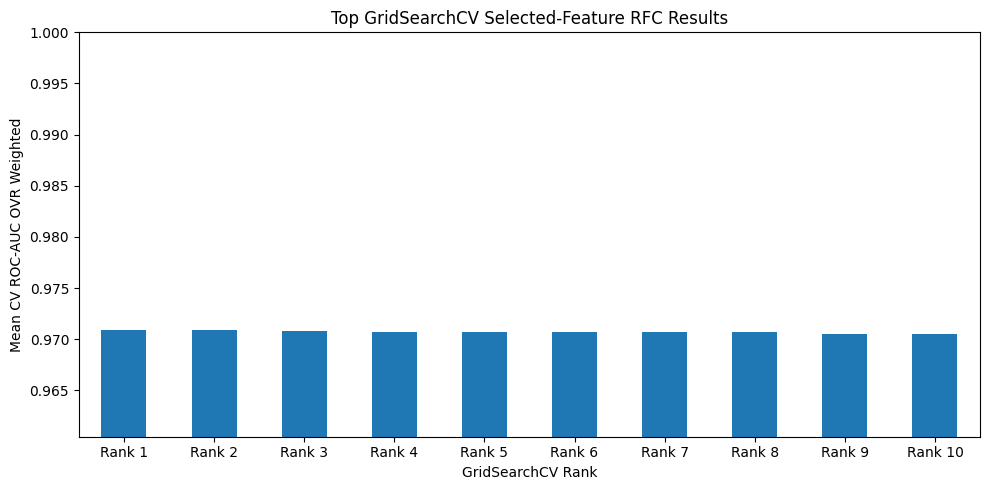

In [16]:
d.plot_gridsearch_top_results(
    gridsearch_summary_df=gridsearch_summary_df,
    figsize=(10, 5)
)


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Discussion Summary

- [Back to Table of Contents](#table-of-contents)

</div>


This section generates report-ready markdown and concise discussion keypoints from the saved artifacts.

Review the generated text before copying it into a README, final report, or slide deck.

In [17]:
discussion_markdown = d.create_discussion_summary_markdown(
    model_comparison_df=model_comparison_df,
    feature_count_summary_df=feature_count_summary_df,
    performance_retention_df=performance_retention_df,
    artifacts=artifacts,
    expected_engineered_feature_count=None
)

display(Markdown(discussion_markdown))



## Highest-SNR Series Discussion Summary

The highest-SNR modeling series compared three progressively more interpretable Random Forest approaches:

1. **Raw I/Q baseline:** flattened each signal from `(1024, 2)` into `2048` raw input features.
2. **All engineered features:** trained on `105` engineered features derived from I/Q statistics, magnitude, power, phase, instantaneous frequency, FFT/spectral behavior, and constellation geometry.
3. **Top selected features:** trained on the top `25` engineered features selected by `information_gain`.

The all-feature engineered model performed best overall, with accuracy of `0.7217` and ROC-AUC of `0.9780`. The top-25 model reduced the feature set by approximately `76.19%` while retaining `96.13%` of the all-feature accuracy and `99.48%` of the all-feature ROC-AUC.

In practical terms, the selected-feature model lost about `2.79` percentage points of accuracy and `0.51` percentage points of ROC-AUC. This suggests that a relatively compact feature subset preserves most of the discriminative information, even though the full engineered-feature model remains the strongest performer.

The major interpretation is that the feature engineering step provided a large improvement over the raw flattened I/Q Random Forest baseline. The top selected features then showed that much of that performance can be maintained with fewer, more interpretable features.


In [18]:
d.print_discussion_keypoints(
    model_comparison_df=model_comparison_df,
    feature_count_summary_df=feature_count_summary_df,
    performance_retention_df=performance_retention_df
)


DISCUSSION KEYPOINTS
Raw I/Q RFC baseline accuracy:      0.3621
All engineered features accuracy:  0.7217
Top selected features accuracy:    0.6937

All engineered feature count:      105
Top selected feature count:        25
Feature reduction:                 76.19%

Top selected-feature retention relative to all engineered features:
              metric  retained_percent  absolute_drop_percentage_points
            accuracy         96.131640                         2.791667
  precision_weighted         96.397544                         2.565005
     recall_weighted         96.131640                         2.791667
roc_auc_ovr_weighted         99.477448                         0.511064



<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Save Discussion Outputs

- [Back to Table of Contents](#table-of-contents)

</div>


This section saves discussion tables, not trained models. The saved CSV files can be reused in reports, READMEs, or presentations.

In [19]:
d.save_discussion_outputs(
    model_comparison_df=model_comparison_df,
    feature_count_summary_df=feature_count_summary_df,
    performance_retention_df=performance_retention_df,
    gridsearch_summary_df=gridsearch_summary_df,
    output_dir=d.DISCUSSION_OUTPUT_DIR
)


DISCUSSION OUTPUTS SAVED
Output directory: ../Reports/discussion



<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Run Full Discussion Workflow

- [Back to Table of Contents](#table-of-contents)

</div>


Instead of running each cell manually, you can run the entire workflow from the helper module.

This remains commented out so the notebook does not accidentally duplicate output while you are presenting the discussion section-by-section.

In [20]:
# Optional full workflow call
# artifacts, model_comparison_df, feature_count_summary_df, performance_retention_df, gridsearch_summary_df = d.main()
